## 1. Data (preparing and loading)

In ML, data can be almost anything.
* Excel spreadsheet
* Images of any kind
* Videos (YT has lots of video data)
* Audios like songs or podcasts
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Buil a model to learn patterns in that numerical 

To showcase this, let's create some *known* data using the linear regression formula

To showcase this, let's create some known data using the linear regression formula.
We'll use a linear regression formula to make a straight line with *known* **parameters**

In [1]:
import torch

# Create known parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim= 1)
y = weight * X + bias

print(X[:10], y[:10]) 
print(len(X), len(y))

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])
50 50


### Splitting data into Training and Testing 

In [2]:
# Create a train-test split
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

print(len(X_train), len(y_train), len(X_test), len(y_test))

40 40 10 10


How might we better visualize our data?

In [3]:
import matplotlib.pyplot as plt

def plot_predictions(train_data=X_train, train_labels=y_train, 
                     test_data=X_test, test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    # Are there predictions?
    if predictions is not None:
        # Plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14});

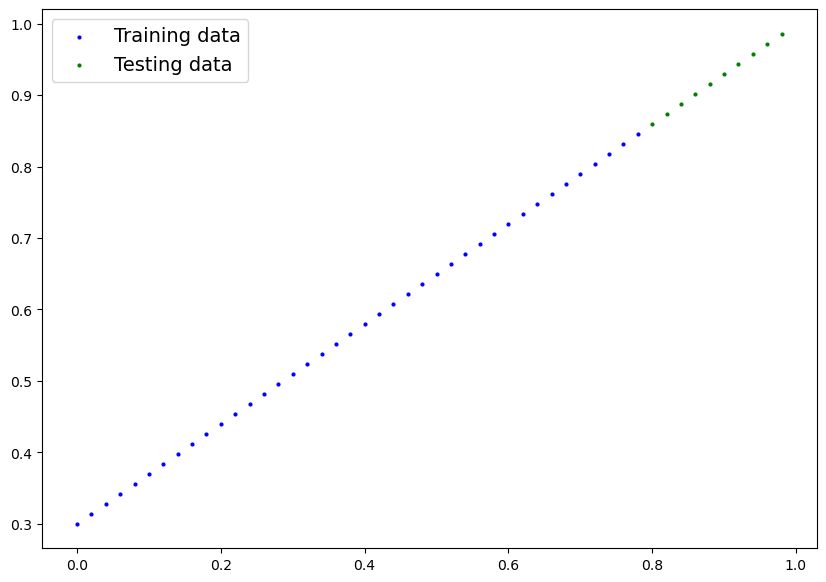

In [4]:
plot_predictions();

## 2. Build Model
Our first PyTorch model!
nn.module: https://docs.pytorch.org/docs/2.12/generated/torch.nn.Module.html

What our model does:
* Start with random values
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient descent - https://youtu.be/IHZwWFHWa-w?si=qzd2-raJCLzjcoE8
2. Backpropogation - https://youtu.be/Ilg3gGewQ5U?si=rEmxYY2i-mvx-IZy

In [5]:
from torch import nn
# Create Linear regression model class

class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherits from nn.module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, 
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))
        
        # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
        return  self.weights * x + self.bias # this is the linear regression equation

### PyTorch model building essentials

* torch.nn - contains all of the buildings for computational graphs (a neural network can be considered a computational graph).
* Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us.
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward().
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent.
* def forward() - All nn.Module subclasses require you to overwrite forward(). This method defines what happens in the forward computation

See more of these essential modules via the PyTorch cheatsheet - https://pytorch-cn.com/tutorials/beginner/ptcheat.html


### Checking the contents of our PyTorch model

Now we've created a model, let's she what is inside...
So we can check our model parameters or what's inside our model using `.parameters()`

In [6]:
# Create a random seed
torch.manual_seed(42)

#Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
print(list(model_0.parameters()))

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [7]:
# List named parameters
print(model_0.state_dict())

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])


### Making predictions using `torch.inference_mode()`

To check the model's predictive power, let's see how well it predicts 'y_test' based on 'X_test'.

When we pass data through our model, it's going to run it through the forward method.

More on inference mode: https://x.com/PyTorch/status/1437838231505096708?lang=en

In [8]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

print(y_preds)
print(y_test)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])
tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


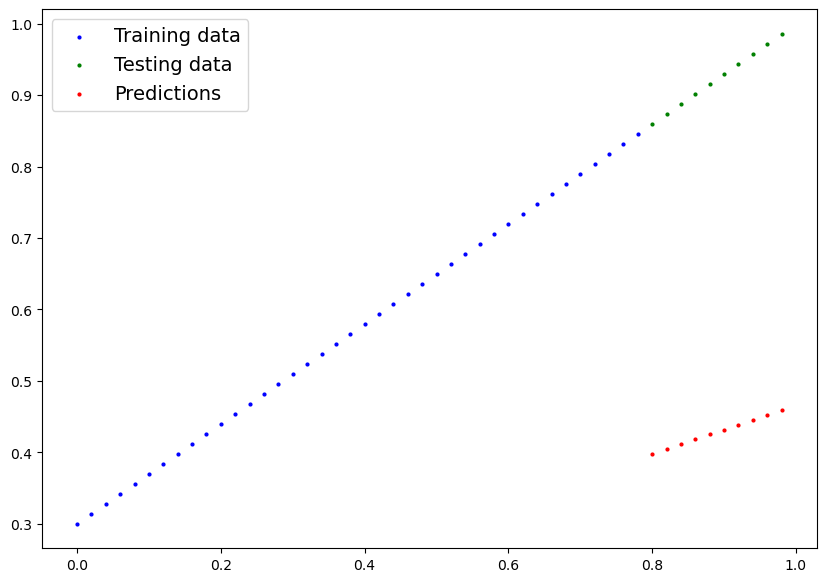

In [9]:
plot_predictions(predictions=y_preds)

### 3. Train Model

The whole idea of training is to move from some *unknown* parameters (these may be random) to some known parameters.
Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor our model's predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas. 


Thing we need to train:
* **Loss Function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:** Takes into account the loss of a model and adjusts the model's paramters (e.g. Weight & Bias in our case) to improve the loss function.

More on Loss Functions: https://docs.pytorch.org/cppdocs/api/nn/loss.html
More on Optimizers: https://docs.pytorch.org/docs/2.12/optim.html

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [10]:
print(model_0.parameters())
print(model_0.state_dict())

<generator object Module.parameters at 0x00000236AD80DCB0>
OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])


In [11]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # lr = learning rate = possibly the most important hyperparameter you can set.


### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation.
2.  Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss. (**backpropagation-** https://youtu.be/Ilg3gGewQ5U?si=8UF9IrFPaNULBZSD)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss. (**gradient descent-** https://youtu.be/IHZwWFHWa-w?si=s8zDPQPLbUQ_CkTq)

In [12]:
# An epoch is one loop through the data (it's a hyperparamter because we've set it)
epochs = 100

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 0. Loop throught the data
for epoch in range(epochs):
    # Set the model to training mode
    model_0.train() # train mode in pytorch sets all parameters that require gradients to require gradients

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculae the loss
    loss = loss_fn(y_pred, y_train)
    print(f"Loss: {loss}")

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step() # by default the optimizer changes will accumulate through the loop so... qw have to zero them above in step 3 for the next iteration of the loop.

    model_0.eval() # turns off different setting in the model not needed for evaluation/testing
    with torch.inference_mode(): # turns off gradient tracking & a couple more things behind 
    # with torch.no_grad(): # you may also see torch.no_grad() in older PyTorch code
        # 1. Do the forward pass
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
        # Print out model state_dict()
        print(model_0.state_dict())





Loss: 0.31288138031959534
Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])
Loss: 0.08227583020925522
Loss: 0

In [13]:
print(model_0.state_dict())

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])


In [14]:
print(weight, bias)

0.7 0.3


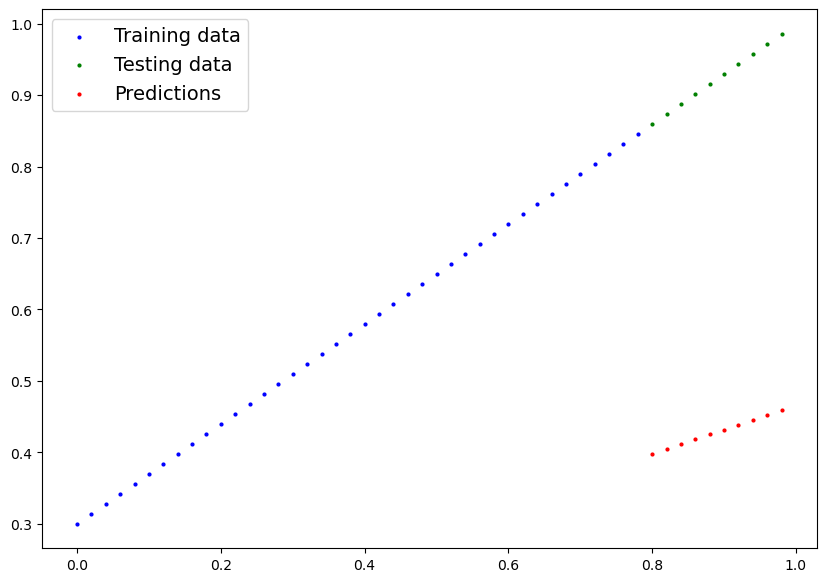

In [15]:
plot_predictions(predictions=y_preds)

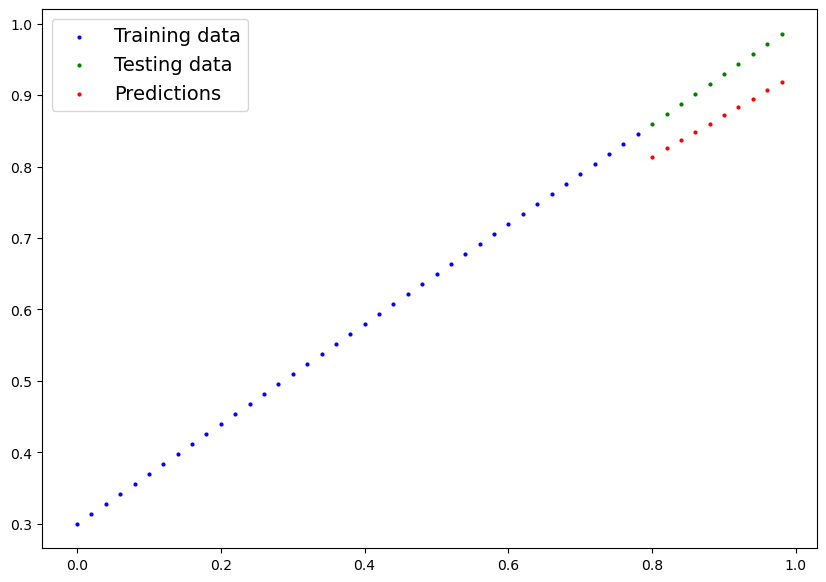

In [16]:
plot_predictions(predictions=test_pred)

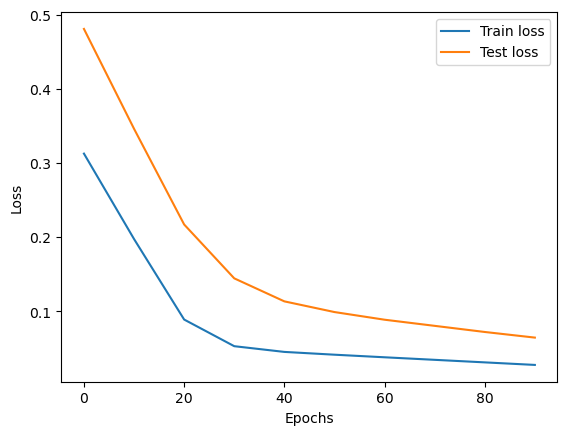

In [17]:
# plot the loss curves
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend();

### Saving a model in PyTorch
There are three main methods you should know about for saving and loading models in PyTorch.

1. `torch.save()` - allows you to save a PyTorch object in Python's pickle format.
2. `torch.load()` - allows you to load a saved PyTorch object.
3. `torch.nn.Module.load_state_dict()` - this allows you to load a model's saved state dictionary.


In [18]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(MODEL_SAVE_PATH)

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

models\01_pytorch_workflow_model_0.pth
Saving model to: models\01_pytorch_workflow_model_0.pth


In [19]:
!ls -l models

total 4
-rw-r--r-- 1 dswan 197609 1680 Jul 14 22:24 01_pytorch_workflow_model_0.pth


In [21]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

C:\Users\dswan\AppData\Local\Temp\ipykernel_14904\1170343677.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH)

<All keys matched successfully>

In [22]:
print(loaded_model_0.state_dict())

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])


In [23]:
# Make some predictions with our loaded model
print(loaded_model_0.eval())
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)
print(loaded_model_preds)

LinearRegressionModel()
tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])


In [ ]:
# Make some model preds 
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

print(y_preds)

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])


In [26]:
# Compare loaded model preds with original model preds
print(y_preds == loaded_model_preds)

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])
